# 🚗 Path Planning – Interpolating Discrete Points

This is where the actual task of **planning a path** begins.

In the real world, we rarely have access to a **continuous set of paths**.  
Instead, we deal with a **limited number of discrete points**, such as waypoints from cone detections or sensor outputs.

Our job is to **connect these discrete points** and generate a smooth and feasible trajectory that the vehicle can follow.

---

## Why Do We Need Interpolation?

Since we cannot drive through isolated points, we must **"connect the dots"** to create a **continuous path**.  
There are different methods for this, and choosing the right one depends on the trade-offs between:
- Accuracy
- Smoothness
- Computation time
- Real-time feasibility

You are encouraged to **explore** these topics online and understand them deeply.  
Your final goal is to **optimize the path**, so analyze each method’s **advantages and disadvantages**.

---

## Suggested Resources

### A) Linear and Quadratic Spline Interpolation
- [Linear & Quadratic Spline Intuition](https://www.youtube.com/watch?v=KLUr1A6vyzs)
- [Quadratic Interpolation Explanation](https://www.youtube.com/watch?v=j_jBK7zJ1vU)
- [Quadratic Spline Derivation](https://www.youtube.com/watch?v=kCPMph3cPA8)

### B) Cubic and Higher-Degree Spline Interpolation
- [Cubic Spline Derivation](https://www.youtube.com/watch?v=wMMjF7kXnWA)
- [Cubic Spline Example](https://www.youtube.com/watch?v=gT7F3TWihvk)

> Try solving the example problem yourself before watching the solution.  
> Now imagine scaling that to **hundreds of points** in real-time path planning!

---

## Assignment

## You are given **four discrete points** in increasing order of x:  
`(x₁, y₁), (x₂, y₂), (x₃, y₃), (x₄, y₄)`

Your task is to:
- **Interpolate these points using Cubic Spline Interpolation**
- **Plot the path obtained.**
- **Do NOT use direct library interpolation functions**
    - You can look up source code online for understanding.
    - But make sure you know **exactly what the code is doing**, step by step.

---

## What to Submit

- Your coded solution (with explanation)
- Analysis of cubic splines vs other interpolation methods
    - Think about smoothness, accuracy, computational cost, and usability in real-time systems

Happy Coding & Exploring!

## 🌟 Optional Assignment

Once you're done with the 4-point cubic spline:

Try writing your **own generic cubic spline interpolation** code for **any number of points (n ≥ 4) taken as input**.

- Again, **do not use `scipy`, `numpy.interp`, or any built-in spline functions**.
- Construct and solve the system of equations manually (or using matrix operations) based on the cubic spline conditions.

This will give you an appreciation of the complexity behind interpolation libraries — and how they are optimized.


Cubic Spline Coefficients:
Interval 0 (0 to 2):
  a = 8.0000, b = -4.2429, c = 0.0000, d = 0.4357
  Polynomial: 8.0000 + -4.2429(x-0) + 0.0000(x-0)² + 0.4357(x-0)³
Interval 1 (2 to 3):
  a = 3.0000, b = 0.9857, c = 2.6143, d = -1.6000
  Polynomial: 3.0000 + 0.9857(x-2) + 2.6143(x-2)² + -1.6000(x-2)³
Interval 2 (3 to 5):
  a = 5.0000, b = 1.4143, c = -2.1857, d = 0.3643
  Polynomial: 5.0000 + 1.4143(x-3) + -2.1857(x-3)² + 0.3643(x-3)³


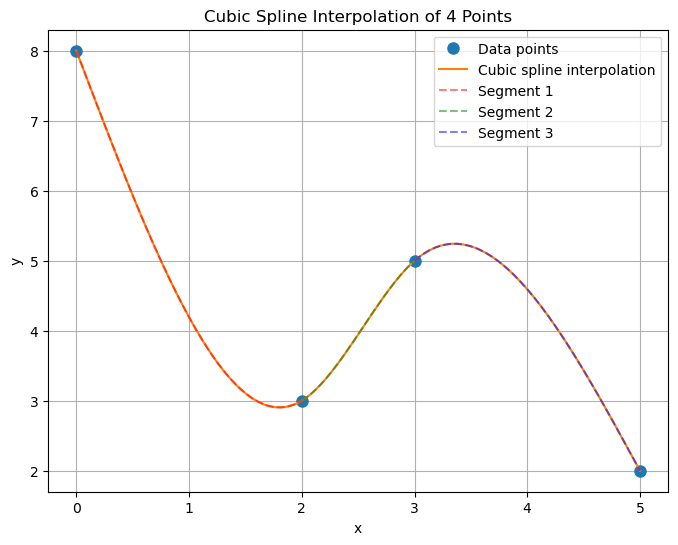

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def cubic_spline_interpolation(x, y):
    """
    Natural cubic spline interpolation for 4 points.
    Returns coefficients (a, b, c, d) for each of the 3 intervals.
    """
    if len(x) != 4 or len(y) != 4:
        raise ValueError("This implementation requires exactly 4 points")
    
    n = 3  # number of intervals (for 4 points)
    h = [x[i+1] - x[i] for i in range(n)]
    
    # Set up the 2x2 system for c1 and c2 (since c0 = c3 = 0 for natural spline)
    # Equation 1: 2(h0+h1)c1 + h1 c2 = 3[(y2-y1)/h1 - (y1-y0)/h0] , got these from the constraints on eqns, after solving them, these can be used for solving for c1 and c2 
    # Equation 2: h1 c1 + 2(h1+h2) c2 = 3[(y3-y2)/h2 - (y2-y1)/h1]
    # after finding c0,c1,c2 we can simply use these values to find bi and di as we have equations for them in terms of c which we got by solving for equations using appropriate conditions
    # Create the matrix and right-hand side

    A = np.array([
        [2*(h[0]+h[1]), h[1]],
        [h[1], 2*(h[1]+h[2])]
    ])
    rhs = np.array([
        3*((y[2]-y[1])/h[1] - (y[1]-y[0])/h[0]),
        3*((y[3]-y[2])/h[2] - (y[2]-y[1])/h[1])
    ])
    
    # Manually solve the 2x2 system Ax = rhs
    det = A[0][0] * A[1][1] - A[0][1] * A[1][0]
    c1 = (A[1][1] * rhs[0] - A[0][1] * rhs[1]) / det
    c2 = (-A[1][0] * rhs[0] + A[0][0] * rhs[1]) / det
    c = [0.0, c1, c2, 0.0]  # Natural spline: c0 = c3 = 0

    
    # Calculate b and d coefficients
    a = y[:-1]
    b = []
    d = []
    for i in range(n):
        b_i = (y[i+1]-y[i])/h[i] - h[i]*(2*c[i]+c[i+1])/3
        d_i = (c[i+1]-c[i])/(3*h[i])
        b.append(b_i)
        d.append(d_i)
    
    # Return coefficients (excluding c3)
    return list(zip(a, b, c[:-1], d))

def evaluate_spline(x_data, coeffs, x):
    """Evaluate spline at point x"""
    if x < x_data[0] or x > x_data[-1]:
        raise ValueError("x is outside interpolation range")
    
    # Find the right interval
    if x <= x_data[1]:
        i = 0
    elif x <= x_data[2]:
        i = 1
    else:
        i = 2
    
    a, b, c, d = coeffs[i]
    dx = x - x_data[i]
    return a + b*dx + c*dx**2 + d*dx**3

def plot_spline(x_data, y_data, coeffs, num_points=100):
    """Plot the spline using matplotlib"""
    plt.figure(figsize=(8, 6))
    
    # Plot original data points
    plt.plot(x_data, y_data, 'o', label='Data points', markersize=8)
    
    # Generate points for the spline curve
    x_vals = np.linspace(min(x_data), max(x_data), num_points)
    y_vals = [evaluate_spline(x_data, coeffs, x) for x in x_vals]
    
    # Plot spline curve
    plt.plot(x_vals, y_vals, '-', label='Cubic spline interpolation')
    
    # Plot each polynomial segment in different colors
    colors = ['red', 'green', 'blue']
    for i in range(3):
        x_segment = np.linspace(x_data[i], x_data[i+1], num_points//3)
        y_segment = [evaluate_spline(x_data, coeffs, x) for x in x_segment]
        plt.plot(x_segment, y_segment, '--', color=colors[i], 
                alpha=0.5, label=f'Segment {i+1}')
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Cubic Spline Interpolation of 4 Points')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage with 4 points
if __name__ == "__main__":
    # Input your 4 points here
    x_data = [0, 2, 3, 5]  # Replace with your x-values
    y_data = [8, 3, 5, 2]  # Replace with your y-values
    
    # Compute spline coefficients
    coeffs = cubic_spline_interpolation(x_data, y_data)
    
    # Print coefficients
    print("Cubic Spline Coefficients:")
    for i, (a, b, c, d) in enumerate(coeffs):
        print(f"Interval {i} ({x_data[i]} to {x_data[i+1]}):")
        print(f"  a = {a:.4f}, b = {b:.4f}, c = {c:.4f}, d = {d:.4f}")
        print(f"  Polynomial: {a:.4f} + {b:.4f}(x-{x_data[i]}) + {c:.4f}(x-{x_data[i]})² + {d:.4f}(x-{x_data[i]})³")
    
    # Plot the results
    plot_spline(x_data, y_data, coeffs)

    
